In [1]:
import os
import glob
import esmpy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"
months = ["01", "04", "07", "10"]

# ERA5
ds_era5_list = []
for mm in months:
    ds_era5_list.append(xr.open_dataset(os.path.join(data_path, f"2021{mm}01_era5/era5_35d_daily.nc")).rename({'valid_time': 'time'}))
ds_era5 = xr.concat(ds_era5_list, dim="dataset", join='outer')
ds_era5 = ds_era5.drop_vars(['valid_time_bnds'])
ds_era5 = ds_era5.assign_coords({"dataset": months})
ds_era5 = ds_era5.reindex(latitude=ds_era5.latitude[::-1])

ds_era5_mean_list = []
for mm in months:
    ds_era5_mean_list.append(xr.open_dataset(os.path.join(data_path, f"2021{mm}01_era5/era5_35d_tmean.nc")).rename({'valid_time': 'time'}))
ds_era5_mean = xr.concat(ds_era5_mean_list, dim="dataset", join='outer')
ds_era5_mean = ds_era5_mean.drop_vars(['valid_time_bnds'])
ds_era5_mean = ds_era5_mean.assign_coords({"dataset": months})
ds_era5_mean = ds_era5_mean.reindex(latitude=ds_era5.latitude[::-1])

# DATM runs
ds_datm_list = []
for mm in months:
    ds_datm_list.append(xr.open_dataset(os.path.join(data_path, f"2021{mm}01_datm/ocn_merged_35d_remap_bil.nc")))
ds_datm = xr.concat(ds_datm_list, dim="dataset", join='outer')
ds_datm = ds_datm.drop_vars(['time_bnds'])
ds_datm = ds_datm.assign_coords({"dataset": months})
ds_datm = ds_datm.reindex(latitude=ds_datm.latitude[::-1])

ds_datm_mean_list = []
for mm in months:
    ds_datm_mean_list.append(xr.open_dataset(os.path.join(data_path, f"2021{mm}01_datm/ocn_merged_35d_remap_bil_tmean.nc")))
ds_datm_mean = xr.concat(ds_datm_mean_list, dim="dataset", join='outer')
ds_datm_mean = ds_datm_mean.drop_vars(['time_bnds'])
ds_datm_mean = ds_datm_mean.assign_coords({"dataset": months})
ds_datm_mean = ds_datm_mean.reindex(latitude=ds_datm_mean.latitude[::-1])

# AURORA 1-WAY
ds_aur1_list = []
for mm in months:
    ds_aur1_list.append(xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora/ocn_merged_35d_remap_bil.nc")))
ds_aur1 = xr.concat(ds_aur1_list, dim="dataset", join='outer')
ds_aur1 = ds_aur1.drop_vars(['time_bnds'])
ds_aur1 = ds_aur1.assign_coords({"dataset": months})
ds_aur1 = ds_aur1.reindex(latitude=ds_aur1.latitude[::-1])

ds_aur1_mean_list = []
for mm in months:
    ds_aur1_mean_list.append(xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora/ocn_merged_35d_remap_bil_tmean.nc")))
ds_aur1_mean = xr.concat(ds_aur1_mean_list, dim="dataset", join='outer')
ds_aur1_mean = ds_aur1_mean.drop_vars(['time_bnds'])
ds_aur1_mean = ds_aur1_mean.assign_coords({"dataset": months})
ds_aur1_mean = ds_aur1_mean.reindex(latitude=ds_aur1_mean.latitude[::-1])

# AURORA 2-WAY
ds_aur2_list = []
for mm in months:
    ds_aur2_list.append(xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora_two_way/ocn_merged_35d_remap_bil.nc")))
ds_aur2 = xr.concat(ds_aur2_list, dim="dataset", join='outer')
ds_aur2 = ds_aur2.drop_vars(['time_bnds'])
ds_aur2 = ds_aur2.assign_coords({"dataset": months})
ds_aur2 = ds_aur2.reindex(latitude=ds_aur2.latitude[::-1])

ds_aur2_mean_list = []
for mm in months:
    ds_aur2_mean_list.append(xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora_two_way/ocn_merged_35d_remap_bil_tmean.nc")))
ds_mean_aur2 = xr.concat(ds_aur2_mean_list, dim="dataset", join='outer')
ds_mean_aur2 = ds_mean_aur2.drop_vars(['time_bnds'])
ds_mean_aur2 = ds_mean_aur2.assign_coords({"dataset": months})
ds_mean_aur2 = ds_mean_aur2.reindex(latitude=ds_mean_aur2.latitude[::-1])

In [2]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"
mm = "10"

ds_era5 = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_era5/era5_35d.nc")).rename({'valid_time': 'time'})
ds_datm = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_datm/ocn_merged_35d_remap_bil.nc"))
ds_aur1 = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora/ocn_merged_35d_remap_bil.nc"))
ds_aur2 = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora_two_way/ocn_merged_35d_remap_bil.nc"))

ds_era5 = ds_era5.reindex(latitude=ds_era5.latitude[::-1])
ds_datm = ds_datm.reindex(latitude=ds_datm.latitude[::-1])
ds_aur1 = ds_aur1.reindex(latitude=ds_aur1.latitude[::-1])
ds_aur2 = ds_aur2.reindex(latitude=ds_aur2.latitude[::-1])

ds_oisst_daily= xr.open_dataset(os.path.join(data_path, f"2021{mm}01_oisst/oisst_35d_remap_bil.nc")).isel(zlev=0)
ds_era5_daily = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_era5/era5_35d_daily.nc")).rename({'valid_time': 'time'})
ds_datm_daily = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_datm/ocn_merged_35d_remap_bil_daily.nc"))
ds_aur1_daily = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora/ocn_merged_35d_remap_bil_daily.nc"))
ds_aur2_daily = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora_two_way/ocn_merged_35d_remap_bil_daily.nc"))

ds_oisst_daily= ds_oisst_daily.reindex(latitude=ds_era5.latitude[::-1])
ds_era5_daily = ds_era5_daily.reindex(latitude=ds_era5_daily.latitude[::-1])
ds_datm_daily = ds_datm_daily.reindex(latitude=ds_datm_daily.latitude[::-1])
ds_aur1_daily = ds_aur1_daily.reindex(latitude=ds_aur1_daily.latitude[::-1])
ds_aur2_daily = ds_aur2_daily.reindex(latitude=ds_aur2_daily.latitude[::-1])

ds_oisst_mean= xr.open_dataset(os.path.join(data_path, f"2021{mm}01_oisst/oisst_35d_remap_bil_tmean.nc")).isel(zlev=0)
ds_era5_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_era5/era5_35d_tmean.nc")).rename({'valid_time': 'time'})
ds_datm_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_datm/ocn_merged_35d_remap_bil_tmean.nc"))
ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm}01_aurora_two_way/ocn_merged_35d_remap_bil_tmean.nc"))

ds_oisst_mean= ds_oisst_mean.reindex(latitude=ds_era5.latitude[::-1])
ds_era5_mean = ds_era5_mean.reindex(latitude=ds_era5_mean.latitude[::-1])
ds_datm_mean = ds_datm_mean.reindex(latitude=ds_datm_mean.latitude[::-1])
ds_aur1_mean = ds_aur1_mean.reindex(latitude=ds_aur1_mean.latitude[::-1])
ds_aur2_mean = ds_aur2_mean.reindex(latitude=ds_aur2_mean.latitude[::-1])

In [3]:
# from https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L40
def _latitude_cell_bounds(x: np.ndarray) -> np.ndarray:
  pi_over_2 = np.array([np.pi / 2], dtype=x.dtype)
  return np.concatenate([-pi_over_2, (x[:-1] + x[1:]) / 2, pi_over_2])
    
# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L45
def _cell_area_from_latitude(points: np.ndarray) -> np.ndarray:
  """Calculate the area overlap as a function of latitude."""
  bounds = _latitude_cell_bounds(points)
  upper = bounds[1:]
  lower = bounds[:-1]
  # normalized cell area: integral from lower to upper of cos(latitude)
  return np.sin(upper) - np.sin(lower)

# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L55
def get_lat_weights(ds: xr.Dataset) -> xr.DataArray:
  """Computes latitude/area weights from latitude coordinate of dataset."""
  weights = _cell_area_from_latitude(np.deg2rad(ds.latitude.data))
  weights /= np.mean(weights)
  weights = ds.latitude.copy(data=weights)
  return weights

# Calculate weights
weights = get_lat_weights(ds_era5)
weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5.longitude.size)))
ds_era5["weights"] = (("latitude", "longitude"), weights2d.data)
ds_era5_daily["weights"] = (("latitude", "longitude"), weights2d.data)
weights = np.cos(np.deg2rad(ds_era5.latitude))
weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5.longitude.size)))
ds_era5["weights2"] = (("latitude", "longitude"), weights2d.data)
ds_era5_daily["weights2"] = (("latitude", "longitude"), weights2d.data)

In [4]:
regions = {
    "Global": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360},
    "Global Land": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_land": True},
    "Global Ocean": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True},
    "Europe": {"lat_min": 35, "lat_max": 70, "lon_min": -10, "lon_max": 40, "over_land": True}, # 35N-70N, 10W-40E
    "North America": {"lat_min": 15, "lat_max": 70, "lon_min": 198, "lon_max": 309, "over_land": True}, # 15N-75N, 140W-50W
    "South America": {"lat_min": -60, "lat_max": 15, "lon_min": 280, "lon_max": 330, "over_land": True}, # 60S-15N, 80W-30W
    "Africa": {"lat_min": -35, "lat_max": 35, "lon_min": -20, "lon_max": 55, "over_land": True}, # 35S-35N, 20W-55E
    "Asia": {"lat_min": 30, "lat_max": 75, "lon_min": 55, "lon_max": 190, "over_land": True}, # 5N-55N, 55E-180E
    "Australia": {"lat_min": -45, "lat_max": -10, "lon_min": 110, "lon_max": 155, "over_land": True}, # 45S-10S, 110E-155E
    "Tropics": {"lat_min": -20, "lat_max": 20, "lon_min": 0, "lon_max": 360}, # 20S-20N, global
    "Nino 1+2": {"lat_min": -10, "lat_max": 0, "lon_min":270 , "lon_max": 280, "over_ocean": True}, # 10S-0N, 90W-80W
    "Nino 3": {"lat_min": -5, "lat_max": 5, "lon_min": 210, "lon_max": 270, "over_ocean": True}, # 5N-5S, 150W-90W
    "Nino 3.4": {"lat_min": -5, "lat_max": 5, "lon_min": 190, "lon_max": 240, "over_ocean": True}, # 5N-5S, 170W-120W
    "Nino 4": {"lat_min": -5, "lat_max": 5, "lon_min": 160, "lon_max": 210, "over_ocean": True}, # 5N-5S, 160E-150W
    "Gulf of Mexico": {"lat_min": 18, "lat_max": 30, "lon_min": 263, "lon_max": 278, "over_ocean": True}, # 18N-30N, 97W-82W
    "North Atlantic Ocean": {"lat_min": 0, "lat_max": 60, "lon_min": 280, "lon_max": 360, "over_ocean": True}, # 0N-60N, 80W-0E
    "Indian Ocean": {"lat_min": -40, "lat_max": 30, "lon_min": 20, "lon_max": 120, "over_ocean": True}, # 40S-30N, 20E-120E
    "Western Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 120, "lon_max": 160, "over_ocean": True}, # 10S-30N, 120E-160E
    "Eastern Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 240, "lon_max": 280, "over_ocean": True}, # 10S-30N, 120W-80W
    "Southern Ocean": {"lat_min": -90, "lat_max": -60, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 90S-60S, global
    "Arctic Ocean": {"lat_min": 60, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 60N-90N, global
}

# Set list of regions
region_list = { 
    "Global": [0.68, 0.02, 0.3, 0.3],
    "Nino 1+2": [0.68, 0.02, 0.3, 0.3],
    "Nino 3": [0.68, 0.02, 0.3, 0.3],
    "Nino 4": [0.02, 0.02, 0.3, 0.3],
    "Nino 3.4": [0.02, 0.02, 0.3, 0.3],
    "Indian Ocean": [0.68, 0.02, 0.3, 0.3],
    "Western Pacific Ocean": [0.02, 0.02, 0.3, 0.3],
    "Eastern Pacific Ocean": [0.02, 0.02, 0.3, 0.3]
}

# Var list
vars = {
    "latent": [[-450, 50], [-25, 25]],
    "sensible": [[-200, 50], [-25, 25]],
    "SW": [[0, 300], [-25, 25]], 
    "LW": [[-150, 50], [-10, 10]]
}

var_map = {
    "latent": "slhf",
    "sensible": "sshf",
    "SW": "ssrd",
    "LW": "str"
}

# Data frame
df = pd.DataFrame(
    columns=[
        "Variable",
        "Month",
        "Simulation",
        "Region",
        "RMSE",
        "NRMSE_STD",
        "NRMSE_MEAN",
        "NRMSE_MINMAX",
        "NRMSE_QUANTILE",
        "Correlation"
    ]
)

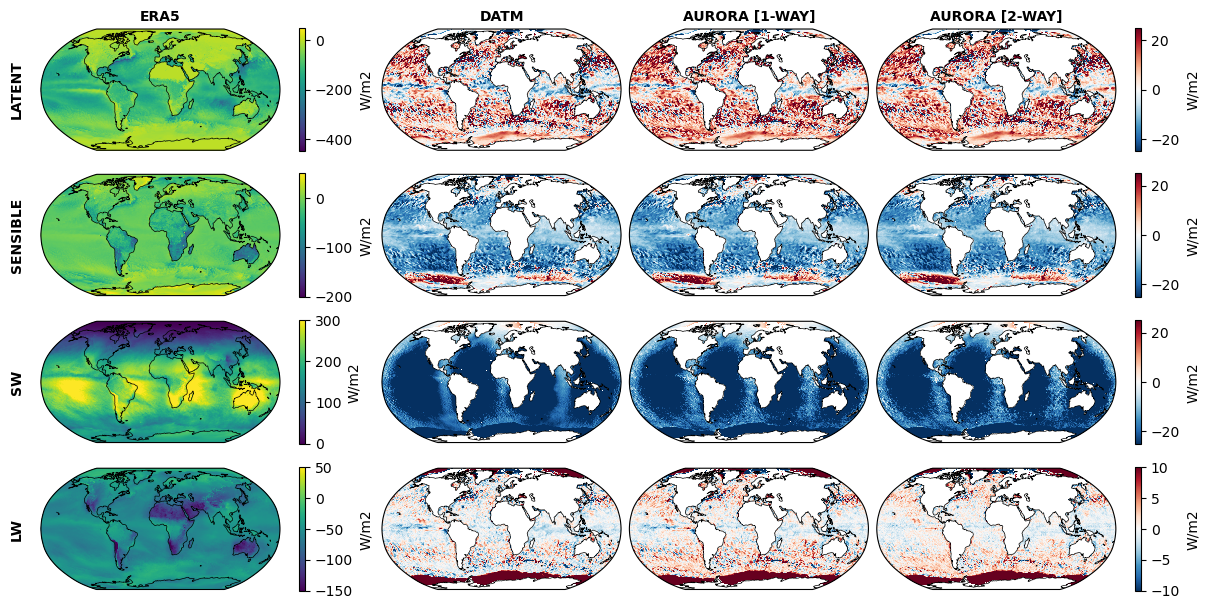

In [7]:
fig, ax = plt.subplots(4, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for v in vars.keys():
    # Set min and max values
    vmin, vmax = vars[v][0]
    vmin_diff, vmax_diff = vars[v][1]

    # ERA5
    data_era5 = ds_era5_mean[var_map[v]].isel(time=0)
    data_era5 = data_era5/3600.0 # J/m2 -> W/m2
    im0 = data_era5.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='viridis', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='W/m2')

    # DATM (ERA5 forced)
    data_datm = ds_datm_mean[v].isel(time=0)
    data_datm = data_datm-data_era5
    im1 = data_datm.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=vmin_diff, vmax=vmax_diff, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)

    # Aurora forced, 1-way coupled
    data_aur1 = ds_aur1_mean[v].isel(time=0)
    data_aur1 = data_aur1-data_era5
    im2 = data_aur1.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=vmin_diff, vmax=vmax_diff, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)

    # Aurora forced, 2-way coupled
    data_aur2 = ds_aur2_mean[v].isel(time=0)
    data_aur2 = data_aur2-data_era5
    im3 = data_aur2.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=vmin_diff, vmax=vmax_diff, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)
    fig.colorbar(im3, ax=ax[irow,3], pad=0.08, aspect=20, shrink=0.9, label='W/m2')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("ERA5", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("DATM", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AURORA [1-WAY]", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AURORA [2-WAY]", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    var_name = v.upper()
    ax[irow,0].text(-0.1, 0.5, f"{var_name}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

In [ ]:
# Time axis
time = ds_era5_daily.indexes['time']#.to_datetimeindex(time_unit='ns')

# Loop over variables
for var in vars:
    print(f"Plotting {var}")
    
    # Calculate number of rows and columns
    nrows = len(region_list) // 2 + len(region_list) % 2
    ncols = 2
    
    # Create figure
    fig, ax = plt.subplots(nrows, ncols, figsize=(12,10), layout='constrained')
    
    # Loop over regions and plot
    i = 0
    for reg, pos in region_list.items():
        irow = i // ncols
        icol = i % ncols
    
        # Get region extent
        lat_min = regions[reg]['lat_min']
        lat_max = regions[reg]['lat_max']
        lon_min = regions[reg]['lon_min']
        lon_max = regions[reg]['lon_max']
    
        # Subset datasets
        ds_era5_subset = ds_era5_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_datm_subset = ds_datm_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_aur1_subset = ds_aur1_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_aur2_subset = ds_aur2_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        
        # Prepare data (area weighted mean)
        data_era5 = ds_era5_subset[var_map[var]].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        data_era5 = data_era5/3600.0 # J/m2 -> W/m2
        data_datm = ds_datm_subset[var].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        data_aur1 = ds_aur1_subset[var].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        data_aur2 = ds_aur2_subset[var].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    
        # Calculate correlation and RMSE
        data = {
            "DATM": data_datm,
            "AURORA 1": data_aur1,
            "AURORA 2": data_aur2
        }
        for label, d in data.items():
            corr = np.corrcoef(d.values, data_era5.values)[0, 1]
            rmse = np.sqrt(np.mean((d.values - data_era5.values) ** 2))
            normalized_rmse_std = rmse/np.std(data_era5.values)
            normalized_rmse_mean = rmse/np.mean(data_era5.values)
            normalized_rmse_minmax = rmse/(np.max(data_era5.values)-np.min(data_era5.values))
            normalized_rmse_quantile = rmse/(np.quantile(data_era5.values, 0.75)-np.quantile(data_era5.values, 0.25))
            #print(f"{label} CORR, RMSE = {corr:.4f}, {rmse:.4f}")
        
        # Plot data
        ax[irow,icol].plot(time, data_era5, label="ERA5")
        ax[irow,icol].plot(time, data_datm, label="DATM")
        ax[irow,icol].plot(time, data_aur1, label="AURORA [1-WAY]")
        ax[irow,icol].plot(time, data_aur2, label="AURORA [2-WAY]")
        ax[irow,icol].legend(ncol=1, fontsize=8, loc='upper right')
        ax[irow,icol].tick_params(axis='x', labelrotation=45)
    
        if irow == nrows-1:
            ax[irow,icol].set_xlabel('Date')
        else:
            ax[irow,icol].set_xticklabels([])
            ax[irow,icol].set_xlabel('')
    
        if icol == 0:
            ax[irow,icol].set_ylabel(f'{var.upper()} [W/m2]')
        else:
            ax[irow,icol].set_ylabel('')
    
        # Add region map
        ax_map = ax[irow,icol].inset_axes(pos, projection=ccrs.PlateCarree(central_longitude=180))
        ax_map.set_global()
        ax_map.coastlines(resolution='110m', color='lightgray', linewidth=0.5)
        patch = mpatches.Rectangle(xy=[lon_min, lat_min],
                                   width=(lon_max - lon_min),
                                   height=(lat_max - lat_min),
                                   transform=ccrs.PlateCarree(),
                                   color='red',
                                   alpha=0.5)
        ax_map.add_patch(patch)

        # Add statistics
        #ax[irow, icol].text(0.02, 0.95, f'{reg}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
        #ax[irow, icol].text(0.02, 0.90, f'CORR: {corr:.2f}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
        #ax[irow, icol].text(0.02, 0.85, f'RMSE: {rmse:.2f}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)

        i=i+1

In [ ]:
# Calculate number of rows and columns
nrows = len(region_list) // 2 + len(region_list) % 2
ncols = 2

# Create figure
fig, ax = plt.subplots(nrows, ncols, figsize=(12,10), layout='constrained')

# Loop over regions and plot
i = 0
for reg, pos in region_list.items():
    # Find out row and column for plot
    irow = i // ncols
    icol = i % ncols
    print(f"Processing {reg}")

    # Get region extent
    lat_min = regions[reg]['lat_min']
    lat_max = regions[reg]['lat_max']
    lon_min = regions[reg]['lon_min']
    lon_max = regions[reg]['lon_max']

    # Subset datasets
    ds_datm_subset = ds_datm_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur1_subset = ds_aur1_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur2_subset = ds_aur2_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))

    # Prepare data (area weighted mean)
    data_datm = ds_datm_subset[var].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur1 = ds_aur1_subset[var].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur2 = ds_aur2_subset[var].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])

    # Print out info
    print(ds_datm_subset.latitude.shape, ds_datm_subset.longitude.shape)

    # Plot data
    ax[irow,icol].plot(time, data_datm, label="DATM")
    ax[irow,icol].plot(time, data_aur1, label="AURORA [1-WAY]")
    ax[irow,icol].plot(time, data_aur2, label="AURORA [2-WAY]")
    ax[irow,icol].legend(ncol=1, fontsize=8, loc='upper right')
    ax[irow,icol].tick_params(axis='x', labelrotation=45)

    if irow == nrows-1:
        ax[irow,icol].set_xlabel('Date')
    else:
        ax[irow,icol].set_xticklabels([])
        ax[irow,icol].set_xlabel('')

    if icol == 0:
        ax[irow,icol].set_ylabel(f'{var.upper()} [K]')
    else:
        ax[irow,icol].set_ylabel('')

    # Add region map
    ax_map = ax[irow,icol].inset_axes(pos, projection=ccrs.PlateCarree(central_longitude=180))
    ax_map.set_global()
    ax_map.coastlines(resolution='110m', color='lightgray', linewidth=0.5)
    patch = mpatches.Rectangle(xy=[lon_min, lat_min],
                                width=(lon_max - lon_min),
                                height=(lat_max - lat_min),
                                transform=ccrs.PlateCarree(),
                                color='red',
                                alpha=0.5)
    ax_map.add_patch(patch)

    i=i+1

FileNotFoundError: [Errno 2] No such file or directory: '/glade/work/turuncu/ML/runs/DLMOM6/analysis/stats_01.nc'

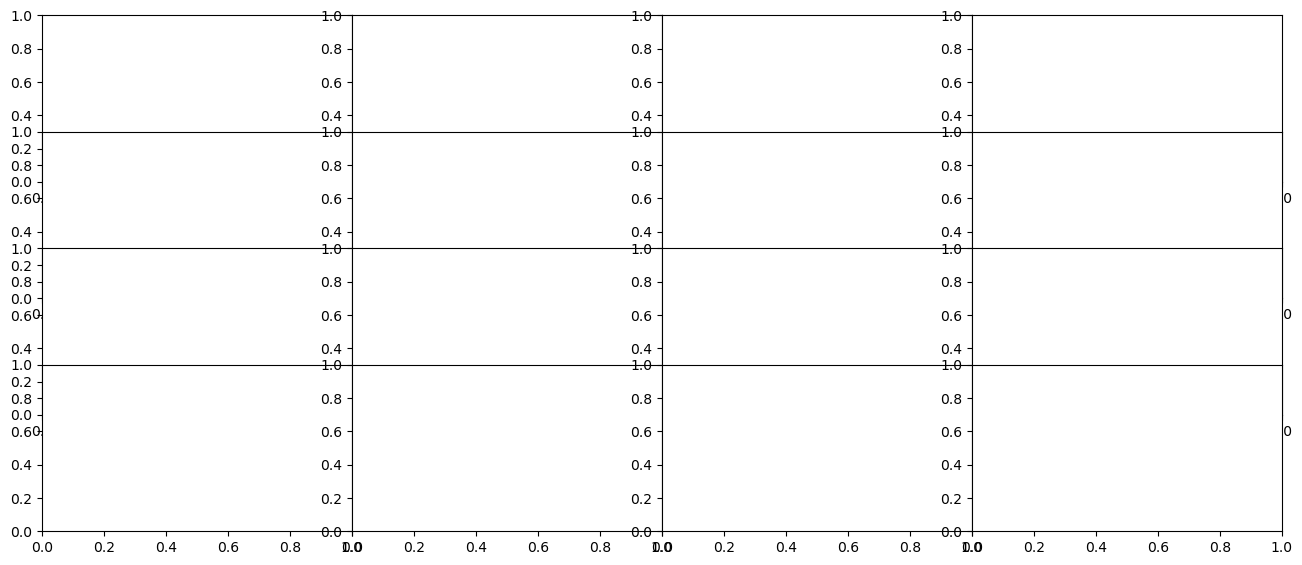

In [6]:
months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

var = "Correlation"

fig, ax = plt.subplots(4, 4, figsize=(16,6.7), gridspec_kw={'wspace': 0.0, 'hspace': -0.3})

irow = 0
for label, val in months.items():
    # Load dataset
    ds = xr.open_dataset(f"stats_{val:02d}.nc")

    # Set list of regions and simulations
    regions = ds.Region.values
    simulations = ds.Simulation.values

    # Plot SW
    data1 = ds[var].sel(Variable='SW').isel(Month=0)
    im1 = ax[irow,0].imshow(data1, cmap="plasma", vmin=0, vmax=1)
    ax[irow,0].set_xticklabels([])
    ax[irow,0].set_xlabel('')
    ax[irow,0].set_yticklabels([])
    ax[irow,0].set_ylabel('')
    ax[irow,0].text(-0.08, 0.5, label, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10, transform=ax[irow,0].transAxes)
    if irow == 0:
        ax[irow,0].set_title("SHORTWAVE", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")

    data = ds.RMSE.sel(Variable='SW').isel(Month=0).values
    for j in range(len(regions)):
        for i in range(len(simulations)):
            text = ax[irow,0].text(j, i, f'{data[i,j]:.1f}', ha="center", va="center", color="w", fontsize=8)
            text.set_color("black")

    # Plot LW
    data2 = ds[var].sel(Variable='LW').isel(Month=0)
    im2 = ax[irow,1].imshow(data2, cmap="plasma", vmin=0, vmax=1)
    ax[irow,1].set_xticklabels([])
    ax[irow,1].set_xlabel('')
    ax[irow,1].set_yticklabels([])
    ax[irow,1].set_ylabel('')
    if irow == 0:
        ax[irow,1].set_title("LONGWAVE", fontweight='bold', fontsize=10)
    else:
        ax[irow,1].set_title("")

    data = ds.RMSE.sel(Variable='LW').isel(Month=0).values
    for j in range(len(regions)):
        for i in range(len(simulations)):
            text = ax[irow,1].text(j, i, f'{data[i,j]:.1f}', ha="center", va="center", color="w", fontsize=8)
            text.set_color("black")

    # Plot latent heat
    data3 = ds[var].sel(Variable='latent').isel(Month=0)
    im3 = ax[irow,2].imshow(data3, cmap="plasma", vmin=0, vmax=1)
    ax[irow,2].set_xticklabels([])
    ax[irow,2].set_xlabel('')
    ax[irow,2].set_yticklabels([])
    ax[irow,2].set_ylabel('')
    if irow == 0:
        ax[irow,2].set_title("LATENT", fontweight='bold', fontsize=10)
    else:
        ax[irow,2].set_title("")

    data = ds.RMSE.sel(Variable='latent').isel(Month=0).values
    for j in range(len(regions)):
        for i in range(len(simulations)):
            text = ax[irow,2].text(j, i, f'{data[i,j]:.1f}', ha="center", va="center", color="w", fontsize=8)
            text.set_color("black")

    # Plot sensible heat
    data4 = ds[var].sel(Variable='sensible').isel(Month=0)
    im4 = ax[irow,3].imshow(data4, cmap="plasma", vmin=0, vmax=1)
    ax[irow,3].set_xticklabels([])
    ax[irow,3].set_xlabel('')
    ax[irow,3].yaxis.tick_right()
    ax[irow,3].tick_params(axis='y', labelright=True, labelleft=False)
    ax[irow,3].set_yticks(range(len(simulations)), labels=simulations, fontsize=10)
    if irow == 0:
        ax[irow,3].set_title("SENSIBLE", fontweight='bold', fontsize=10)
    else:
        ax[irow,3].set_title("")

    data = ds.RMSE.sel(Variable='sensible').isel(Month=0).values
    for j in range(len(regions)):
        for i in range(len(simulations)):
            text = ax[irow,3].text(j, i, f'{data[i,j]:.1f}', ha="center", va="center", color="w", fontsize=8)
            text.set_color("black")

    # Add region labels
    if irow == 3:
        for icol in range(0,4):
            ax[irow,icol].set_xticks(range(len(regions)), labels=regions, rotation=45, ha="right", rotation_mode="anchor")

    irow = irow+1

cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
fig.colorbar(ax[0,0].images[0], cax=cbar_ax, label='Correlation Coefficient [0-1]')

ax[0,0].text(-0.2, -1.0, 'Starting Month for 35d Long Simulations', rotation=90, ha='center', va='center', fontweight='bold', fontsize=10, transform=ax[0,0].transAxes)

In [ ]:
# Time axis
time = ds_era5_daily.indexes['time']#.to_datetimeindex(time_unit='ns')

# Loop over variables
for var in vars:
    print(f"Plotting {var}")
    
    # Calculate number of rows and columns
    nrows = len(region_list) // 2 + len(region_list) % 2
    ncols = 2
    
    # Create figure
    fig, ax = plt.subplots(nrows, ncols, figsize=(12,10), layout='constrained')
    
    # Loop over regions and plot
    i = 0
    for reg, pos in region_list.items():
        irow = i // ncols
        icol = i % ncols
    
        # Get region extent
        lat_min = regions[reg]['lat_min']
        lat_max = regions[reg]['lat_max']
        lon_min = regions[reg]['lon_min']
        lon_max = regions[reg]['lon_max']
    
        # Subset datasets
        ds_era5_subset = ds_era5_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_datm_subset = ds_datm_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_aur1_subset = ds_aur1_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_aur2_subset = ds_aur2_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        
        # Prepare data (area weighted mean)
        data_era5 = ds_era5_subset[var_map[var]].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        data_era5 = data_era5/3600.0 # J/m2 -> W/m2
        data_datm = ds_datm_subset[var].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        data_aur1 = ds_aur1_subset[var].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        data_aur2 = ds_aur2_subset[var].weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    
        # Calculate correlation and RMSE
        data = {
            "DATM": data_datm,
            "AURORA 1": data_aur1,
            "AURORA 2": data_aur2
        }
        for label, d in data.items():
            corr = np.corrcoef(d.values, data_era5.values)[0, 1]
            rmse = np.sqrt(np.mean((d.values - data_era5.values) ** 2))
            normalized_rmse_std = rmse/np.std(data_era5.values)
            normalized_rmse_mean = rmse/np.mean(data_era5.values)
            normalized_rmse_minmax = rmse/(np.max(data_era5.values)-np.min(data_era5.values))
            normalized_rmse_quantile = rmse/(np.quantile(data_era5.values, 0.75)-np.quantile(data_era5.values, 0.25))
            #print(f"{label} CORR, RMSE = {corr:.4f}, {rmse:.4f}")
        
        # Plot data
        ax[irow,icol].plot(time, data_era5, label="ERA5")
        ax[irow,icol].plot(time, data_datm, label="DATM")
        ax[irow,icol].plot(time, data_aur1, label="AURORA [1-WAY]")
        ax[irow,icol].plot(time, data_aur2, label="AURORA [2-WAY]")
        ax[irow,icol].legend(ncol=1, fontsize=8, loc='upper right')
        ax[irow,icol].tick_params(axis='x', labelrotation=45)
    
        if irow == nrows-1:
            ax[irow,icol].set_xlabel('Date')
        else:
            ax[irow,icol].set_xticklabels([])
            ax[irow,icol].set_xlabel('')
    
        if icol == 0:
            ax[irow,icol].set_ylabel(f'{var.upper()} [W/m2]')
        else:
            ax[irow,icol].set_ylabel('')
    
        # Add region map
        ax_map = ax[irow,icol].inset_axes(pos, projection=ccrs.PlateCarree(central_longitude=180))
        ax_map.set_global()
        ax_map.coastlines(resolution='110m', color='lightgray', linewidth=0.5)
        patch = mpatches.Rectangle(xy=[lon_min, lat_min],
                                   width=(lon_max - lon_min),
                                   height=(lat_max - lat_min),
                                   transform=ccrs.PlateCarree(),
                                   color='red',
                                   alpha=0.5)
        ax_map.add_patch(patch)

        # Add statistics
        #ax[irow, icol].text(0.02, 0.95, f'{reg}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
        #ax[irow, icol].text(0.02, 0.90, f'CORR: {corr:.2f}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
        #ax[irow, icol].text(0.02, 0.85, f'RMSE: {rmse:.2f}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)

        i=i+1

In [2]:
# from https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L40
def _latitude_cell_bounds(x: np.ndarray) -> np.ndarray:
  pi_over_2 = np.array([np.pi / 2], dtype=x.dtype)
  return np.concatenate([-pi_over_2, (x[:-1] + x[1:]) / 2, pi_over_2])
    
# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L45
def _cell_area_from_latitude(points: np.ndarray) -> np.ndarray:
  """Calculate the area overlap as a function of latitude."""
  bounds = _latitude_cell_bounds(points)
  upper = bounds[1:]
  lower = bounds[:-1]
  # normalized cell area: integral from lower to upper of cos(latitude)
  return np.sin(upper) - np.sin(lower)

# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L55
def get_lat_weights(ds: xr.Dataset) -> xr.DataArray:
  """Computes latitude/area weights from latitude coordinate of dataset."""
  weights = _cell_area_from_latitude(np.deg2rad(ds.latitude.data))
  weights /= np.mean(weights)
  weights = ds.latitude.copy(data=weights)
  return weights

In [7]:
regions = {
    "Global": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360},
    "Global Land": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_land": True},
    "Global Ocean": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True},
    "Europe": {"lat_min": 35, "lat_max": 70, "lon_min": -10, "lon_max": 40, "over_land": True}, # 35N-70N, 10W-40E
    "North America": {"lat_min": 15, "lat_max": 70, "lon_min": 198, "lon_max": 309, "over_land": True}, # 15N-75N, 140W-50W
    "South America": {"lat_min": -60, "lat_max": 15, "lon_min": 280, "lon_max": 330, "over_land": True}, # 60S-15N, 80W-30W
    "Africa": {"lat_min": -35, "lat_max": 35, "lon_min": -20, "lon_max": 55, "over_land": True}, # 35S-35N, 20W-55E
    "Asia": {"lat_min": 30, "lat_max": 75, "lon_min": 55, "lon_max": 190, "over_land": True}, # 5N-55N, 55E-180E
    "Australia": {"lat_min": -45, "lat_max": -10, "lon_min": 110, "lon_max": 155, "over_land": True}, # 45S-10S, 110E-155E
    "Tropics": {"lat_min": -20, "lat_max": 20, "lon_min": 0, "lon_max": 360}, # 20S-20N, global
    "Nino 1+2": {"lat_min": -10, "lat_max": 0, "lon_min":270 , "lon_max": 280, "over_ocean": True}, # 10S-0N, 90W-80W
    "Nino 3": {"lat_min": -5, "lat_max": 5, "lon_min": 210, "lon_max": 270, "over_ocean": True}, # 5N-5S, 150W-90W
    "Nino 3.4": {"lat_min": -5, "lat_max": 5, "lon_min": 190, "lon_max": 240, "over_ocean": True}, # 5N-5S, 170W-120W
    "Nino 4": {"lat_min": -5, "lat_max": 5, "lon_min": 160, "lon_max": 210, "over_ocean": True}, # 5N-5S, 160E-150W
    "Gulf of Mexico": {"lat_min": 18, "lat_max": 30, "lon_min": 263, "lon_max": 278, "over_ocean": True}, # 18N-30N, 97W-82W
    "North Atlantic Ocean": {"lat_min": 0, "lat_max": 60, "lon_min": 280, "lon_max": 360, "over_ocean": True}, # 0N-60N, 80W-0E
    "Indian Ocean": {"lat_min": -40, "lat_max": 30, "lon_min": 20, "lon_max": 120, "over_ocean": True}, # 40S-30N, 20E-120E
    "Western Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 120, "lon_max": 160, "over_ocean": True}, # 10S-30N, 120E-160E
    "Eastern Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 240, "lon_max": 280, "over_ocean": True}, # 10S-30N, 120W-80W
    "Southern Ocean": {"lat_min": -90, "lat_max": -60, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 90S-60S, global
    "Arctic Ocean": {"lat_min": 60, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 60N-90N, global
    "Antarctic Ocean": {"lat_min": -90, "lat_max": -50, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 50S-90S, global
}

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

JAN 1
APR 4
JUL 7
OCT 10


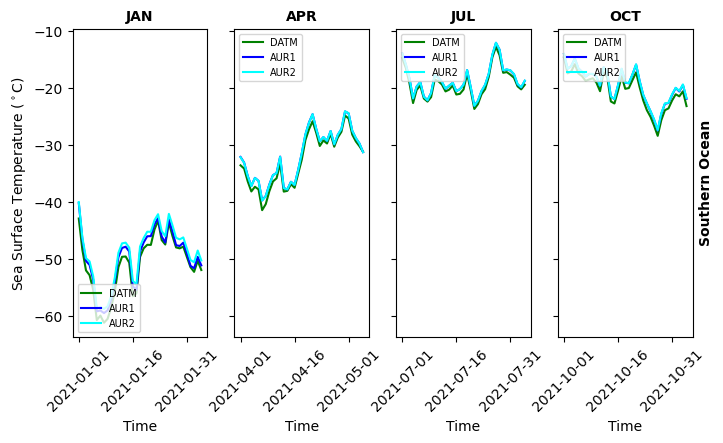

In [32]:
# Set region
reg = "Southern Ocean"
#reg = "Global"
#reg = "Arctic Ocean"
#reg = "North Atlantic Ocean"
#reg = "Nino 3.4"
#reg = "Nino 4"
#reg = "Nino 3"
#reg = "Western Pacific Ocean"
#reg = "Eastern Pacific Ocean"
#reg = "Global Ocean"

#model_var = "latent"
model_var = "sensible"
model_var = "LW"
#model_var = "SW"
#model_var = "LwLatSens"
#model_var = "Heat_PmE"

# Create composite time axis
t1 = pd.date_range(start='2021-01-01', end='2021-02-04', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
t2 = pd.date_range(start='2021-04-01', end='2021-05-05', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
t3 = pd.date_range(start='2021-07-01', end='2021-08-04', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
t4 = pd.date_range(start='2021-10-01', end='2021-11-04', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
time_arr = t1+t2+t3+t4

fig, ax = plt.subplots(1, 4, figsize=(8, 4), sharey=True)#, layout='constrained')

indx = 0
for label, val in months.items():
    print(label, val)
    # Load datasets
    ds_datm_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil_daily.nc"))
    ds_aur1_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_daily.nc"))
    ds_aur2_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/ocn_merged_35d_remap_bil_daily.nc"))

    ds_datm_daily = ds_datm_daily.reindex(latitude=ds_datm_daily.latitude[::-1])
    ds_aur1_daily = ds_aur1_daily.reindex(latitude=ds_aur1_daily.latitude[::-1])
    ds_aur2_daily = ds_aur2_daily.reindex(latitude=ds_aur2_daily.latitude[::-1])

    # Calculate weights
    weights = get_lat_weights(ds_datm_daily)
    weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_datm_daily.longitude.size)))
    ds_datm_daily["weights"] = (("latitude", "longitude"), weights2d.data)
    weights = np.cos(np.deg2rad(ds_datm_daily.latitude))
    weights = weights / weights.mean()
    weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_datm_daily.longitude.size)))
    ds_datm_daily["weights2"] = (("latitude", "longitude"), weights2d.data)

    # Get region extent
    lat_min = regions[reg]['lat_min']
    lat_max = regions[reg]['lat_max']
    lon_min = regions[reg]['lon_min']
    lon_max = regions[reg]['lon_max']

    # Subset datasets
    ds_datm_subset = ds_datm_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur1_subset = ds_aur1_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur2_subset = ds_aur2_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max)) 

    # Calculate correlation and RMSE
    #data = {
    #    "ERA5": ds_era5_subset,
    #    "DATM": ds_datm_subset,
    #    "AUR1": ds_aur1_subset,
    #    "AUR2": ds_aur2_subset
    #}
    #RMSE_dict = {}
    #CORR_dict = {}
    #for label2, d in data.items():
    #    RMSE = np.sqrt(((d.sst - ds_oisst_subset.sst) ** 2).weighted(weights).mean(dim=['latitude', 'longitude']))
    #    RMSE = RMSE.mean(dim=['time']).values
    #    RMSE_dict[label2] = RMSE
    #    CORR = CORR.mean(dim=['time']).values
    #    CORR = xs.pearson_r(ds_oisst_subset.sst, d.sst, skipna=True, dim=['latitude', 'longitude'])
    #    CORR_dict[label2] = CORR

    # Create mask
    #ds_oisst = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil.nc")).isel(zlev=0)
    #ds_oisst = ds_oisst.reindex(latitude=ds_oisst.latitude[::-1])
    #ds_oisst_subset = ds_oisst.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    #ice_mask = ds_oisst_subset.ice.notnull() #*100 # > 15
    #data_mask = ds_era5_subset.sst.notnull()
    #dmask = data_mask #(data_mask | ice_mask)
    #dmask.isel(time=0).plot()
    #sys.exit()
    # Create mask
    dmask = ds_datm_subset.SST.notnull()
    
    # Calculate area weighted mean
    data_datm = ds_datm_subset[model_var].where(dmask).weighted(ds_datm_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur1 = ds_aur1_subset[model_var].where(dmask).weighted(ds_datm_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur2 = ds_aur2_subset[model_var].where(dmask).weighted(ds_datm_subset.weights).mean(dim=["longitude", "latitude"])

    # Plot
    time = data_datm.time.values
    ax[indx].plot(time, data_datm, color='green', label=f"DATM")
    ax[indx].plot(time, data_aur1, color='blue', label=f"AUR1")
    ax[indx].plot(time, data_aur2, color='cyan', label=f"AUR2")

    # Rotate x tick labels
    ax[indx].set_xticks(time[::15])
    ax[indx].tick_params(axis='x', labelrotation=45)
    ax[indx].set_xlabel('Time')

    # Handle axises
    if indx == 0:
        ax[indx].spines['left'].set_visible(True)
        ax[indx].set_ylabel(r'Sea Surface Temperature ($^\circ$C)')
    else:
        ax[indx].set_ylabel('')
    if indx == 3:
        ax[indx].spines['right'].set_visible(True)

    # Add title
    ax[indx].set_title(f"{label}", fontweight='bold', fontsize=10)

    # Add legend
    if indx in [0]:
        ax[indx].legend(ncol=1, fontsize=7, loc='lower left')
    else:
        ax[indx].legend(ncol=1, fontsize=7, loc='upper left')

    # Add text
    if indx == 3:
        ax[indx].text(1.1, 0.5, f"{reg}", transform=ax[indx].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    indx = indx+1

filename = f"timeseries_sst_{reg}.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

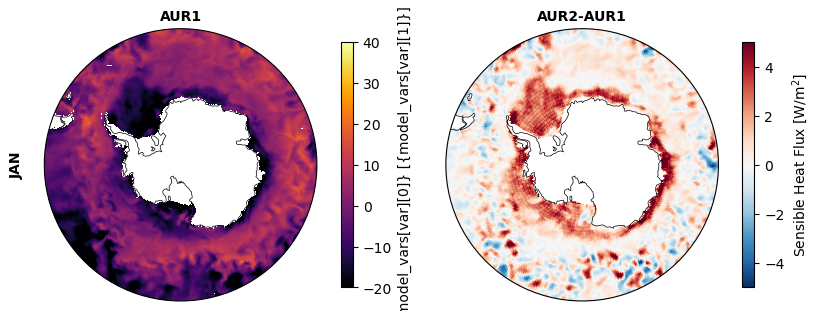

In [34]:
import matplotlib.path as mpath

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(1, 2, figsize=(8, 3), layout='constrained', subplot_kw={'projection': proj})

# Month
mm = 1
label = "JAN"

# Model var
#model_var = "latent"
model_var = "sensible"
#model_var = "LW"
#model_var = "SW"
#model_var = "LwLatSens"
#model_var = "Heat_PmE"
model_vars = {
    "sensible": ["Sensible Heat Flux", "W/m$^2$", -20, 40, -5, 5],
}
var = "sensible"

# Set min and max
vmin = model_vars[var][2]
vmax = model_vars[var][3]
vmin_diff = model_vars[var][4]
vmax_diff = model_vars[var][5]

# Load datasets
ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora_two_way/ocn_merged_35d_remap_bil_tmean.nc"))

# MOM6: Aurora forced (1-way)
data_aur1 = ds_aur1_mean[var].isel(time=0)
im0 = data_aur1.plot(ax=ax[0], transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='inferno', add_colorbar=False)
ax[0].coastlines(linewidth=0.5)
ax[0].set_boundary(circle, transform=ax[0].transAxes)
ax[0].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
fig.colorbar(im0, ax=ax[0], pad=0.08, aspect=20, shrink=0.9, label=r"{model_vars[var][0]} [{model_vars[var][1]}]")

# MOM6: Aurora forced (2-way)
data_aur2 = ds_aur2_mean[var].isel(time=0)
data_aur2 = data_aur2-data_aur1
im1 = data_aur2.plot(ax=ax[1], transform=ccrs.PlateCarree(), vmin=vmin_diff, vmax=vmax_diff, cmap='RdBu_r', add_colorbar=False)
ax[1].coastlines(linewidth=0.5)
ax[1].set_boundary(circle, transform=ax[1].transAxes)
ax[1].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
fig.colorbar(im1, ax=ax[1], pad=0.08, aspect=20, shrink=0.9, label=f"{model_vars[var][0]} [{model_vars[var][1]}]")

# Labels
ax[0].set_title("AUR1", fontweight='bold', fontsize=10)
ax[1].set_title("AUR2-AUR1", fontweight='bold', fontsize=10)
ax[0].text(-0.1, 0.5, f"{label}", transform=ax[0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

# Save to file
filename = "added_value_sh_sst.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)